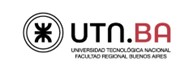

In [58]:
pip install pytc2

###**Trabajo Practico de Laboratorio 1**
**Teoria de los Circuitos 2**


Autor: Alan Nicolas Parizek

Integrantes: Alan Nicolas Parizek,
             Matias Marchesi,
             Martin Silvosa


Profesor: Mariano Llamedo Soria  
Ayudante de TPs: David Moharos  
Jefe de TPs: César Fuoco  




In [62]:
import sympy as sp
import numpy as np
from pytc2.remociones import remover_polo_dc
from pytc2.general import print_latex, s
from pytc2.sistemas_lineales import bodePlot, pretty_print_SOS, tf2sos_analog
import scipy.signal as sig

In [63]:
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from pytc2.sistemas_lineales import analyze_sys, bodePlot, pzmap, pretty_print_bicuad_omegayq

# módulo de SciPy
from scipy import signal as sig

# Esta parte de código la agregamos SOLO en los notebooks para fijar el estilo de los gráficos.
fig_sz_x = 13
fig_sz_y = 7
fig_dpi = 80 # dpi
fig_font_size = 13

mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size':fig_font_size})

#consigna


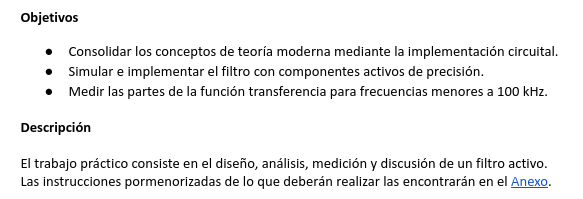

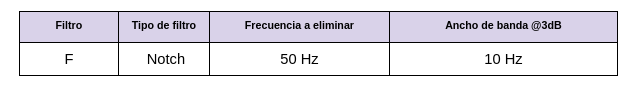

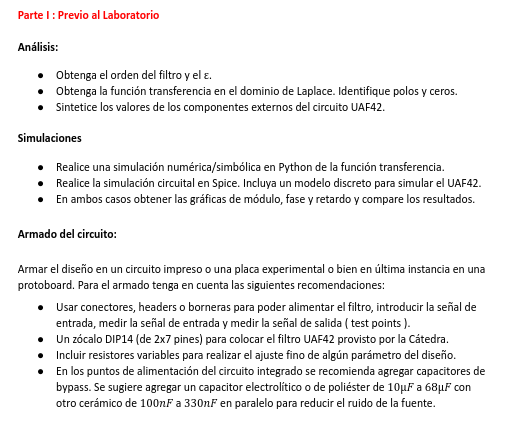

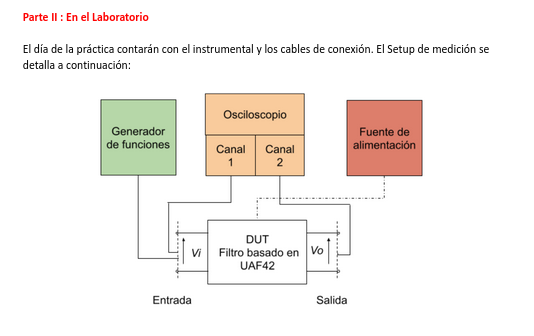

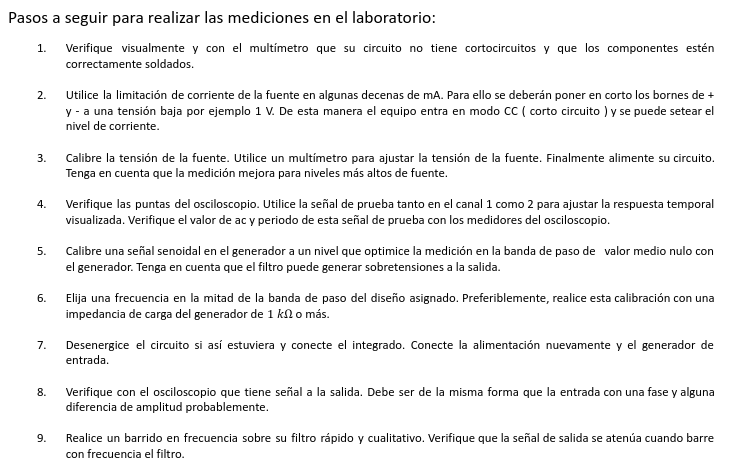

### 1. Especificaciones y parámetros iniciales

* Atenuación máxima en banda de paso: $\alpha_{\max} = 3\text{ dB}$
* Ancho de banda de corte: $BW = 10\text{ Hz}$
* Frecuencia central de rechazo: $f_0 = 50\text{ Hz} \implies \omega_0 = 2\pi f_0$
* Factor de calidad:
  $$Q = \frac{f_0}{BW} = \frac{50\text{ Hz}}{10\text{ Hz}} = 5$$

Como la transformación frecuencial duplica el orden ($N = 2n$), se parte de un prototipo pasabajo Butterworth normalizado de orden $n = 1$:

$$T_{\text{LP}}($) = \frac{1}{$ + 1}$$

---

### 2. Transformación Pasabajo a Rechaza-banda (Notch)

La transformación normalizada hacia la variable compleja $s$ está dada por:

$$$ = \frac{1}{Q} \left( \frac{s\,\omega_0}{s^2 + \omega_0^2} \right)$$

Sustituyendo $p$ en el prototipo pasabajo:

$$T(s) = \left. T_{\text{LP}}($) \right|_{$ = \frac{1}{Q} \frac{s \omega_0}{s^2 + \omega_0^2}} = \frac{1}{\dfrac{1}{Q} \left( \dfrac{s\,\omega_0}{s^2 + \omega_0^2} \right) + 1}$$

---

### 3. Obtengo


$$T(s) = \frac{s^2 + \omega_0^2}{s^2 + \dfrac{\omega_0}{Q}s + \omega_0^2}$$

---

### 4. Sustitución numérica

Con $\omega_0 = 2\pi(50) = 100\pi \approx 314.16\text{ rad/s}$ y $Q = 5$:

* $\omega_0^2 = (100\pi)^2 = 10000\pi^2 \approx 98696.04$
* $\dfrac{\omega_0}{Q} = \dfrac{100\pi}{5} = 20\pi \approx 62.83\text{ rad/s} = 2\pi \cdot BW$

La función de transferencia final desnormalizada queda:

$$T(s) = \frac{s^2 + (100\pi)^2}{s^2 + 20\pi s + (100\pi)^2} \approx \frac{s^2 + 98696.04}{s^2 + 62.83s + 98696.04}$$

La transferencia normalizada queda:

$$T(s) = \frac{s^2 + 1}{s^2 + 0.2s + 1}$$

(2, <Axes: xlabel='$\\sigma$', ylabel='j$\\omega$'>)

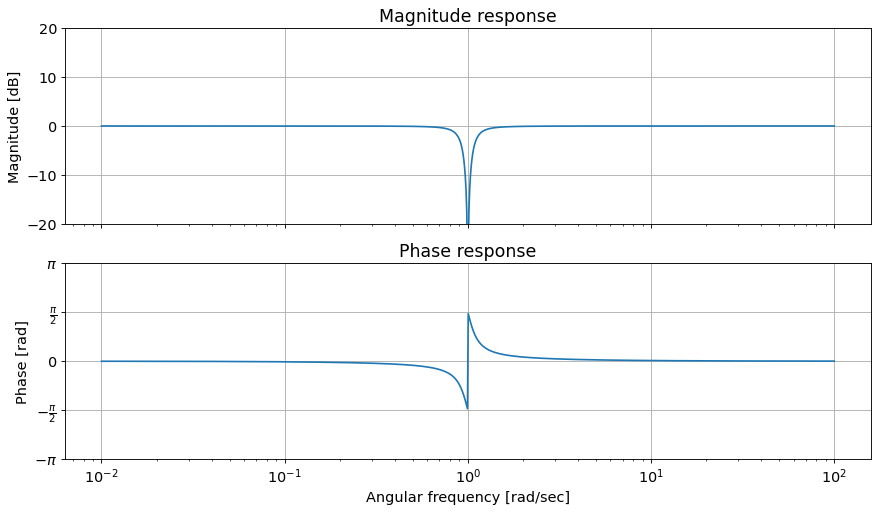

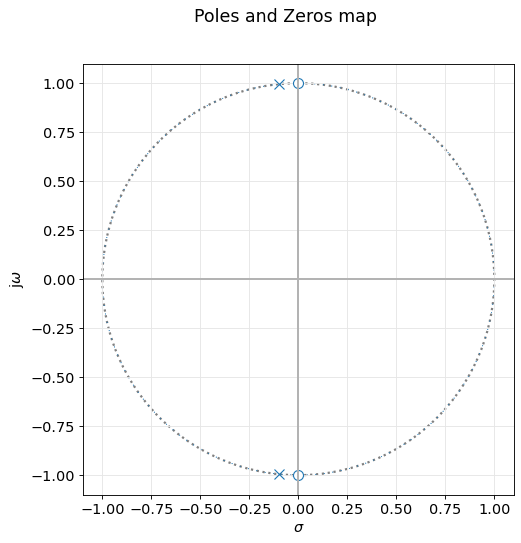

In [20]:
num= np.array([1, 0, 1])
den = np.array([1, 0.2, 1])

TF = sig.TransferFunction(num, den)

_, axes_hdl = bodePlot(TF)

plt.sca(axes_hdl[0])
plt.ylim(-20, 20)
pzmap(TF)

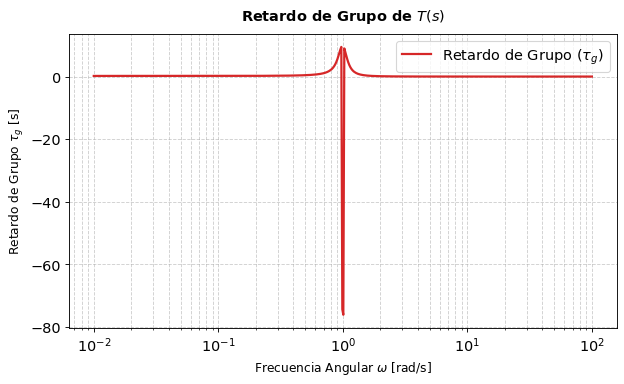

Retardo de grupo máximo: 9.473889 s (9473.889 ms)
Ocurre a omega:          0.973 rad/s
Ocurre a frecuencia f:   0.155 Hz


In [56]:
w, H = sig.freqresp(TF, w=w)

# 3. Fase continua en radianes
fase_rad = np.unwrap(np.angle(H))

# 4. Retardo de grupo: tau_g = -d(phi) / d(omega)
retardo_grupo = -np.gradient(fase_rad, w)

# 5. Graficar
plt.figure(figsize=(8, 5))
plt.plot(w, retardo_grupo, color='#d62728', linewidth=2, label='Retardo de Grupo ($\\tau_g$)')
plt.xscale('log')
plt.title('Retardo de Grupo de $T(s)$', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Frecuencia Angular $\\omega$ [rad/s]', fontsize=11)
plt.ylabel('Retardo de Grupo $\\tau_g$ [s]', fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

idx_max = np.argmax(retardo_grupo)
max_tau_g = retardo_grupo[idx_max]
w_max = w[idx_max]
f_max = w_max / (2 * np.pi)  # Convertir a Hz

# Imprimir resultados en consola
print(f"Retardo de grupo máximo: {max_tau_g:.6f} s ({max_tau_g * 1000:.3f} ms)")
print(f"Ocurre a omega:          {w_max:.3f} rad/s")
print(f"Ocurre a frecuencia f:   {f_max:.3f} Hz")

Obtencion de la transferencia KHN

In [66]:

# Parámetros:
Y1, Y2, Y3, Y4, Y5, Y6, Y7, Y8, Y9, Y10, Y11 = sp.symbols("Y1, Y2, Y3, Y4, Y5, Y6, Y7, Y8, Y9, Y10, Y11")
Vi, Vo, Va, Vb, Vc, Vd, Ve, Vf, Vg = sp.symbols("Vi, Vo, Va, Vb, Vc, Vd, Ve, Vf, Vg")
G1, G2, G3, G4, G5, G6, G7, G8, G9, C1, C2, wt, w0 = sp.symbols("G1, G2, G3, G4, G5, G6, G7, G8, G9, C1, C2, wt, w0", real=True, positive=True)
s = sp.symbols('s')

eq1 = Va*(Y3+Y10+Y1+Y2) - Vi*Y3 - Vb*Y10 - Vb*Y1 - Vf*Y2
eq2 = Va*1
eq3 = Vc*(Y4+Y11) - Vb*Y4 - Vd*Y11
eq4 = Vc*1
eq5 = Ve*(Y5+Y6) - Vd*Y5 - Vf*Y6
eq6 = Ve*1
eq7 = Vg*(Y8+Y7+Y9) - Vb*Y8 - Vi*Y7 - Vo*Y9
eq8 = Vg*1

solucion = sp.solve([eq1, eq2, eq3, eq4, eq5, eq6, eq7, eq8], [Vo, Va, Vb, Vc, Vd, Ve, Vf, Vg], dict=True)

Vo_resuelto = solucion[0][Vo]

T = sp.simplify(Vo_resuelto / Vi)

print_latex(sp.latex(sp.Eq(sp.Symbol('T(s)'), T)))

T_s = T.subs({
    Y1: G1,
    Y2: G2,
    Y3: G3,
    Y4: G4,
    Y5: G5,
    Y6: G6,
    Y7: G7,
    Y8: G8,
    Y9: G9,
    Y10: s*C1,
    Y11: s*C2
})

T_s = sp.together(T_s)
T_s = sp.factor(T_s)
T_s = sp.simplify(T_s)

# CORRECCIÓN
print_latex(sp.latex(sp.Eq(sp.Symbol('T(s)'), T_s)))

# Factor divisor para normalizar coeficientes:
divisor = C1*C2*G6*G9

# sp.fraction separa la expresión en (numerador, denominador)
num, den = sp.fraction(T_s)

# Dividimos cada parte por el factor y agrupamos por s
num_dividido = sp.collect(sp.expand(num / divisor), s, evaluate=sp.simplify)
den_dividido = sp.collect(sp.expand(den / divisor), s, evaluate=sp.simplify)

# Reconstruimos la transferencia normalizada
T_s = num_dividido / den_dividido

# CORRECCIÓN
print_latex(sp.latex(sp.Eq(sp.Symbol('T(s)'), T_s)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

$$T(s) = -\frac{G7}{G9} \cdot \frac{s^2 + s \cdot \left(\frac{G1}{C1} - \frac{G3G8}{C1G7}\right) + \frac{G2G4G5}{C1C2G6}}{s^2 + s \cdot \frac{G1}{C1} + \frac{G2G4G5}{C1C2G6}}$$

$$G1 = G3 = Ga; \quad G9 = G8 = G7 = G6 = G5 = Gb; \quad G4 = G2 = Gc; \quad C1 = C2 = C;$$

Simplificando:

$$T(s) = -\frac{s^2 + \frac{Gc^2}{C^2}}{s^2 + s \cdot \frac{Ga}{C} + \frac{Gc^2}{C^2}}$$

$$\omega_0^2 = \frac{Gc^2}{C^2} \rightarrow \omega_0 = \frac{Gc}{C}$$

$$\frac{\omega_0}{Q} = \frac{Ga}{C}$$

Con $\omega_0 = 2\pi(50) = 100\pi \approx 314.16\text{ rad/s}$ y $Q = 5$:

$$Gc = \frac{1}{R}$$

$$Ga \cdot Q = \omega_0 \cdot C \rightarrow Ga \cdot Q = Gc \rightarrow R1 = R3 = R \cdot Q$$

$$\omega_0 = \frac{1}{RC}$$

$$\omega_0 = 2\pi \cdot 50Hz = 314.159 \frac{rad}{seg}$$

$$C1 = C2 = C = 100nF$$

$$R = \frac{1}{314.159 \cdot 100nF} = 31830\Omega \rightarrow R2 = R4 = R = 32K\Omega$$

$$R1 = R3 = R2 Q = 160K\Omega$$

$$R5 = R6 = R7 = R8 = R9 = 10K\Omega$$

Simulacion Circuital

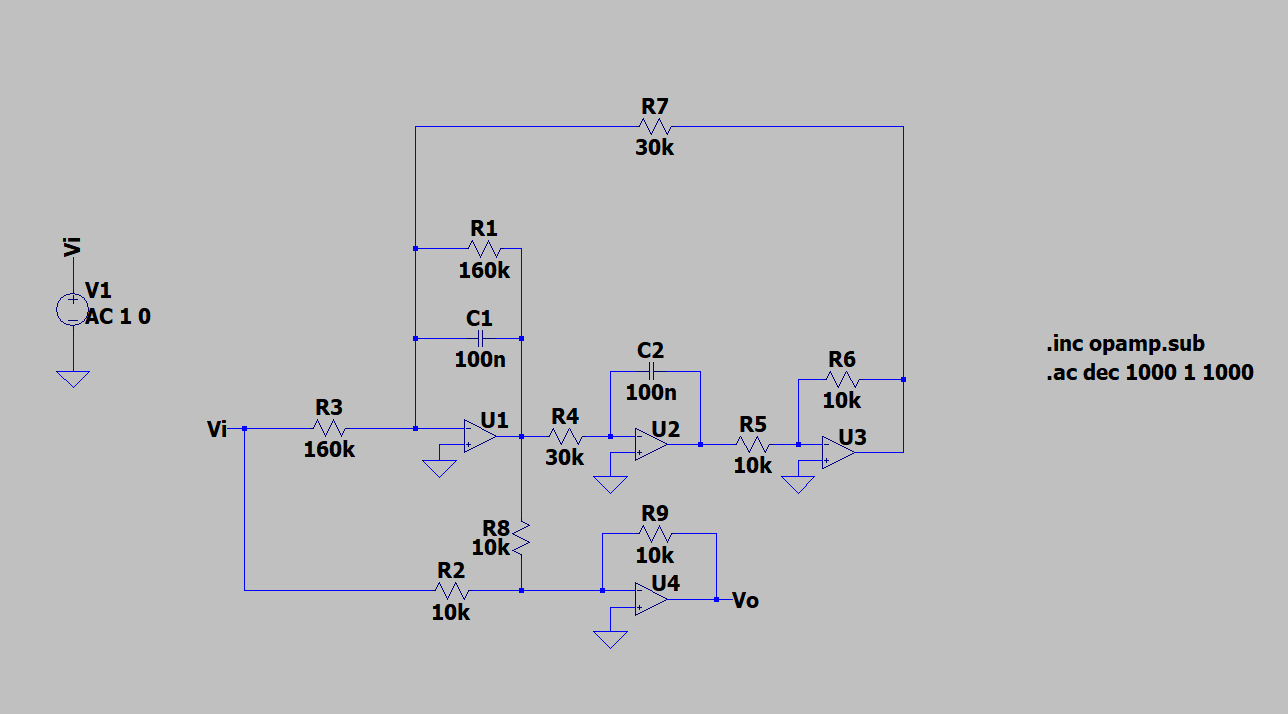

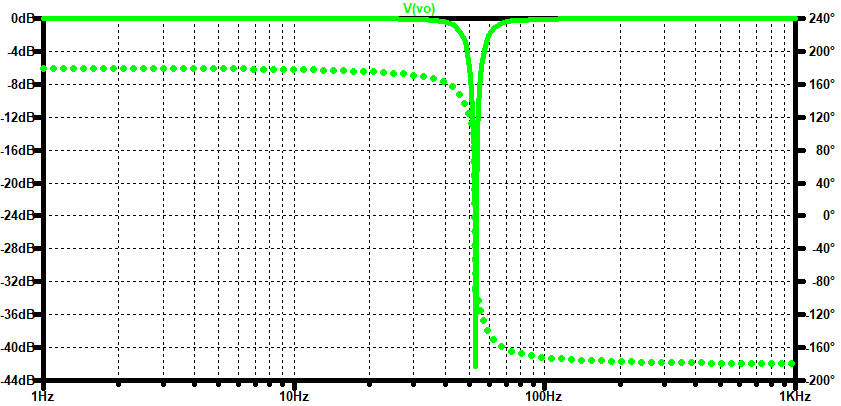

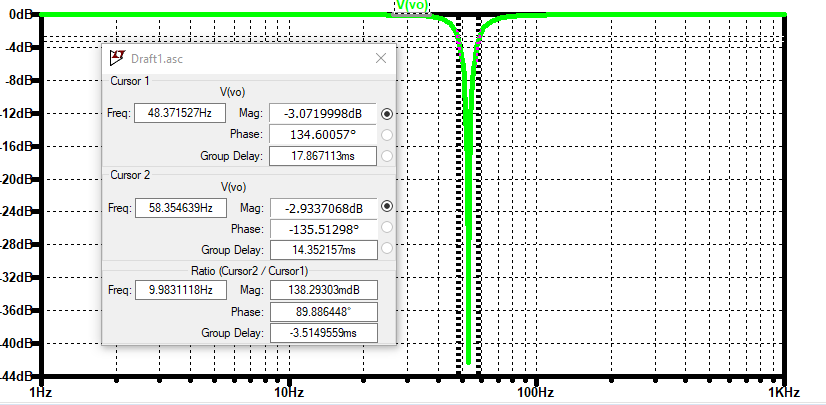

Se puede ver el ancho de banda de 10Hz

#Resultados de la Practica

Se realizo la practica con una placa con el siguiente esquematico:

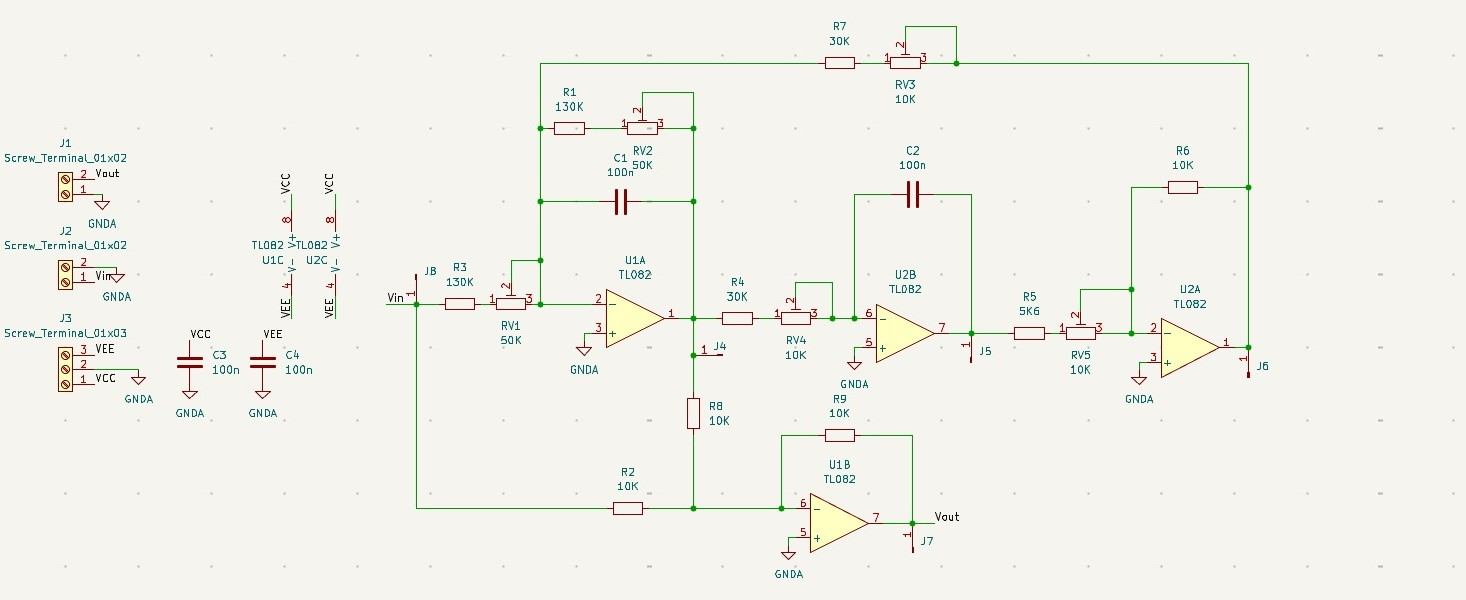

A continuacion, se muestran los resultados del barrido en frecuencia realizado al circuito. El mismo se hizo con una senoidal de 10Vpp.

Text(0, 0.5, 'volts')

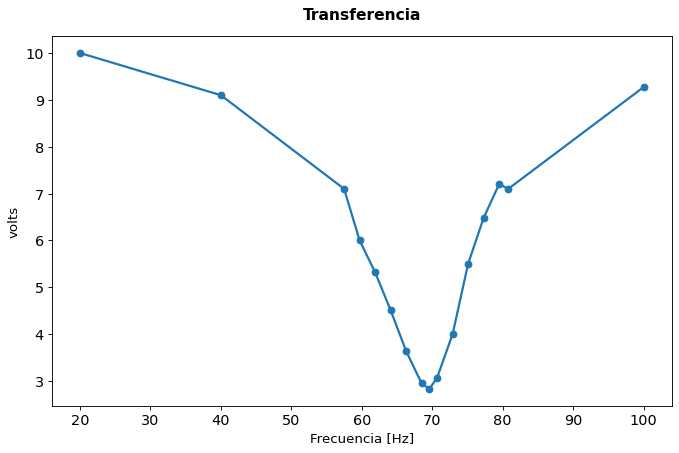

In [31]:
# Datos extraídos de la tabla seleccionada (G3:H19)
frecuencia = [
    20.0, 40.0, 57.5, 59.7, 61.9, 64.1, 66.3, 68.5,
    69.6, 70.7, 72.9, 75.1, 77.3, 79.5, 80.8, 100.0
]

ganancia = [
    10.0, 9.1, 7.1, 6.0, 5.32, 4.51, 3.64, 2.95,
    2.83, 3.07, 4.0, 5.5, 6.48, 7.2, 7.1, 9.27
]

# Configuración del gráfico
plt.figure(figsize=(10, 6))
plt.plot(frecuencia, ganancia, marker='o', linestyle='-', color='#1f77b4', linewidth=2, label='Ganancia')

# Título y etiquetas de los ejes
plt.title('Transferencia', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Frecuencia [Hz]', fontsize=12)
plt.ylabel('volts', fontsize=12)

Text(0, 0.5, 'dB')

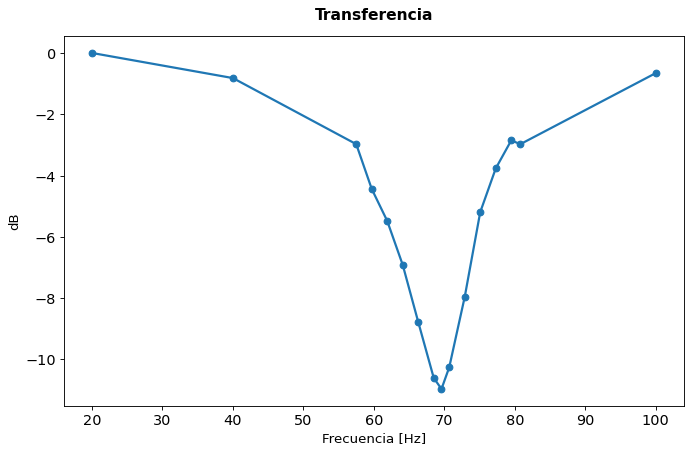

In [30]:
ganancia_array = np.array(ganancia)

# 2. Ahora la fórmula funcionará perfectamente (se aplica a todos los números a la vez)
ganancia_dB = 20 * np.log10(ganancia_array / 10)

# Configuración del gráfico
plt.figure(figsize=(10, 6))
plt.plot(frecuencia, ganancia_dB, marker='o', linestyle='-', color='#1f77b4', linewidth=2, label='Ganancia')

# Título y etiquetas de los ejes
plt.title('Transferencia', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Frecuencia [Hz]', fontsize=12)
plt.ylabel('dB', fontsize=12)

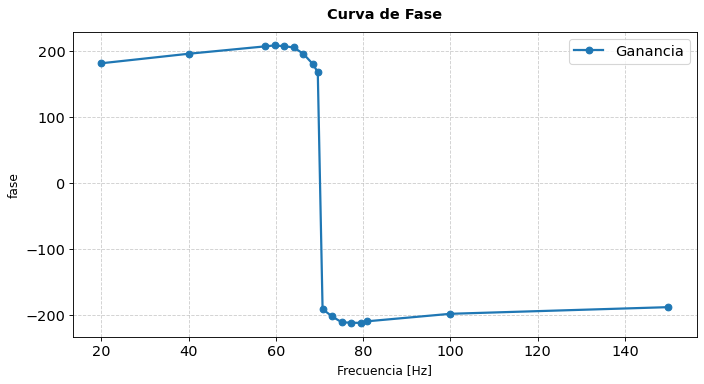

In [50]:
# Datos de la selección (J3:K19)
frecuencia = [
    20.0, 40.0, 57.5, 59.7, 61.9, 64.1, 66.3, 68.5,
    69.6, 70.7, 72.9, 75.1, 77.3, 79.5, 80.8, 100.0, 150.0
]

fase_ms = [
    25.2, 13.6, 10.0, 9.7, 9.3, 8.9, 8.2, 7.3,
    6.7, -7.5, -7.7, -7.8, -7.6, -7.4, -7.2, -5.5, -3.48
]

fase_ms_array = np.array(fase_ms)
frecuencia_array = np.array(frecuencia)

fase_grados = fase_ms_array * frecuencia_array * 0.36

# Configuración del gráfico
plt.figure(figsize=(9, 5))
plt.plot(frecuencia, fase_grados, marker='o', linestyle='-', color='#1f77b4', linewidth=2, label='Ganancia')

# Etiquetas y título
plt.title('Curva de Fase', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Frecuencia [Hz]', fontsize=11)
plt.ylabel('fase', fontsize=11)

# Cuadrícula y detalles visuales
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()

# Mostrar gráfico
plt.show()

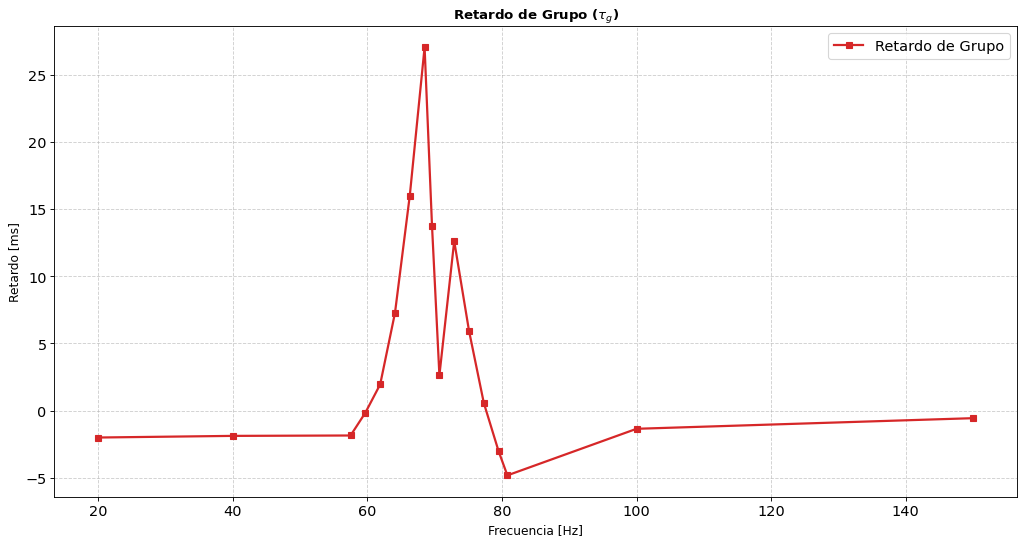

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# Datos experimentales
frecuencia = [
    20.0, 40.0, 57.5, 59.7, 61.9, 64.1, 66.3, 68.5,
    69.6, 70.7, 72.9, 75.1, 77.3, 79.5, 80.8, 100.0, 150.0
]

fase_ms = [
    25.2, 13.6, 10.0, 9.7, 9.3, 8.9, 8.2, 7.3,
    6.7, -7.5, -7.7, -7.8, -7.6, -7.4, -7.2, -5.5, -3.48
]

frecuencia_array = np.array(frecuencia)
fase_ms_array = np.array(fase_ms)

# 1. Fase en grados y radianes
fase_grados = fase_ms_array * frecuencia_array * 0.36
fase_rad = np.unwrap(np.deg2rad(fase_grados))  # unwrap para evitar discontinuidades de 2pi

# 2. Frecuencia angular en rad/s
omega = 2 * np.pi * frecuencia_array

# 3. Retardo de Fase: tau_p = -phi / omega
retardo_fase_ms = (-fase_rad / omega) * 1000

# 4. Retardo de Grupo: tau_g = -d(phi) / d(omega)
dphi_domega = np.gradient(fase_rad, omega)
retardo_grupo_ms = -dphi_domega * 1000



# Subplot 2: Retardo de Grupo
plt.plot(frecuencia_array, retardo_grupo_ms, marker='s', linestyle='-', color='#d62728', linewidth=2, label='Retardo de Grupo')
plt.title('Retardo de Grupo ($\\tau_g$)', fontsize=12, fontweight='bold')
plt.xlabel('Frecuencia [Hz]', fontsize=11)
plt.ylabel('Retardo [ms]', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best', frameon=True)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1516/750906491.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best')


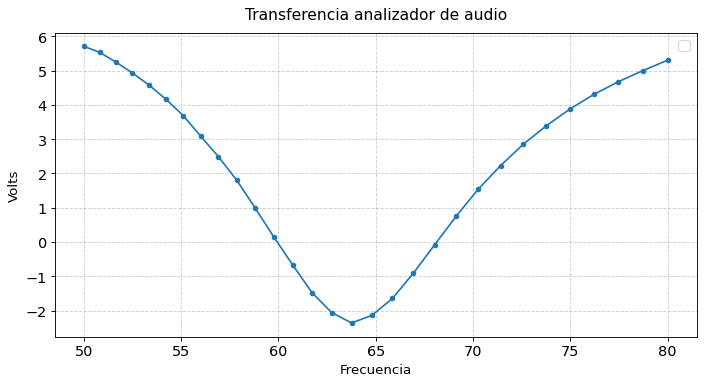

In [45]:
# Valores de la Columna D (eje X)
x = [
    50, 50.81695339, 51.64725504, 52.49112305, 53.34877907,
    54.22044839, 55.10635998, 56.00674653, 56.92184457, 57.85189445,
    58.79714048, 59.75783095, 60.7342182, 61.72655872, 62.73511315,
    63.76014642, 64.80192778, 65.86073088, 66.93683383, 68.0305193,
    69.14207457, 70.27179162, 71.41996719, 72.58690288, 73.77290521,
    74.97828572, 76.20336102, 77.44845291, 78.71388843, 80
]

# Valores de la Columna E (eje Y)
y = [
    5.708784463, 5.534931429, 5.249739927, 4.936915496, 4.58131834,
    4.167507442, 3.691291841, 3.08852622, 2.487434108, 1.809001359,
    1.000232681, 0.1530094001, -0.6675794557, -1.476179056, -2.057170954,
    -2.360913917, -2.140468547, -1.64699558, -0.9074278997, -0.07777347892,
    0.7577385556, 1.543258739, 2.231318362, 2.854398017, 3.393319834,
    3.879419, 4.304670699, 4.671943025, 4.997687473, 5.305469847
]

plt.figure(figsize=(9, 5))
plt.plot(x, y, marker='o', markersize=4, linestyle='-', color='#1f77b4')

# Título y etiquetas
plt.title('Transferencia analizador de audio', fontsize=14, pad=12)
plt.xlabel('Frecuencia', fontsize=12)
plt.ylabel('Volts', fontsize=12)

# Cuadrícula y leyenda
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best')

# Ajuste visual y muestra del gráfico
plt.tight_layout()
plt.show()

#Conclusiones

Se puede ver que hay una diferencia en el f0 respecto a lo simulado. Atribuimos esto a errores en la calibracion de la placa. Tambien se puede ver el ancho de banda de 10Hz.